In [ ]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel
from dataset import create_dataloaders


## Step 1: 创建Lu数据集的CSV文件


In [ ]:
PROJECT_ROOT = script_dir.parent.parent
LU_AUDIO_DIR = PROJECT_ROOT / "data/raw/Lu_Patient_merged"
LU_FEATURES_DIR = PROJECT_ROOT / "data/processed/lu_features"
LU_CSV_PATH = PROJECT_ROOT / "data/processed/lu-test.csv"

# 创建特征目录
LU_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# 收集Lu数据集的音频文件
lu_samples = []

for label_dir in ["Control", "Dementia"]:
    audio_dir = LU_AUDIO_DIR / label_dir
    if not audio_dir.exists():
        print(f"⚠️ 目录不存在: {audio_dir}")
        continue
    
    label = 0 if label_dir == "Control" else 1
    
    for audio_file in sorted(audio_dir.glob("*_merged.wav")):
        session_id = audio_file.stem.replace("_merged", "")
        feature_path = f"data/processed/lu_features/{session_id}.egemaps.pt"
        
        lu_samples.append({
            "session_id": session_id,
            "egemaps_path": feature_path,
            "ad": label,
            "audio_path": str(audio_file.relative_to(PROJECT_ROOT))
        })

# 创建CSV
lu_df = pd.DataFrame(lu_samples)
lu_df.to_csv(LU_CSV_PATH, index=False)

print(f"✅ Lu数据集CSV已创建: {LU_CSV_PATH}")
print(f"   总样本数: {len(lu_df)}")
print(f"   Control: {(lu_df['ad'] == 0).sum()}")
print(f"   Dementia: {(lu_df['ad'] == 1).sum()}")

✅ Lu数据集CSV已创建: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/lu-test.csv
   总样本数: 53
   Control: 25
   Dementia: 28


## Step 2: 为Lu数据集提取eGeMAPS特征


In [11]:
import librosa
import numpy as np
from opensmile.core.smile import Smile
from opensmile.core.define import FeatureSet, FeatureLevel
from tqdm.auto import tqdm
import warnings

FEAT_SEQ_LEN = 10
SAMPLING_RATE = 16000

def extract_egemaps_for_lu():
    """为Lu数据集提取eGeMAPS特征"""
    
    print("=" * 60)
    print("为 Lu 数据集提取 eGeMAPS 特征")
    print("=" * 60)

    # 初始化 OpenSMILE
    smile_lld = Smile(
        feature_set=FeatureSet.eGeMAPSv02,
        feature_level=FeatureLevel.LowLevelDescriptors,
    )
    
    # 读取CSV
    lu_df = pd.read_csv(LU_CSV_PATH)
    
    extracted = 0
    skipped = 0
    
    warnings.simplefilter('ignore')
    
    for idx, row in tqdm(lu_df.iterrows(), total=len(lu_df), desc="提取特征"):
        audio_path_abs = PROJECT_ROOT / row['audio_path']
        egemaps_path_abs = PROJECT_ROOT / row['egemaps_path']
        
        # 检查是否已存在
        if egemaps_path_abs.exists():
            skipped += 1
            continue
        
        try:
            # 1. 加载音频
            audio_np, _ = librosa.load(str(audio_path_abs), sr=SAMPLING_RATE, res_type="kaiser_best")
            audio_np = librosa.to_mono(audio_np)
            audio_np = np.float32(audio_np)
            
            # 2. 音频分段
            usable_length = (audio_np.shape[0] // FEAT_SEQ_LEN) * FEAT_SEQ_LEN
            if usable_length == 0:
                print(f"\n⚠️ 音频太短: {row['session_id']}")
                continue
            
            audio_segments = np.split(audio_np[:usable_length], FEAT_SEQ_LEN)
            
            # 3. 逐段提取特征
            egemaps_list = []
            for segment in audio_segments:
                _, _, features = smile_lld.process(segment, SAMPLING_RATE)
                egemaps_list.append(torch.from_numpy(features[0, :]))
            
            # 4. 堆叠为 (10, 25)
            egemaps = torch.stack(egemaps_list, dim=0)
            
            # 5. 保存
            egemaps_path_abs.parent.mkdir(parents=True, exist_ok=True)
            torch.save(egemaps, egemaps_path_abs)
            
            extracted += 1
            
        except Exception as e:
            print(f"\n❌ 提取失败 {row['session_id']}: {e}")
            continue
    
    warnings.simplefilter('always')
    
    print(f"\n  特征提取完成!")
    print(f"   新提取: {extracted}")
    print(f"   已跳过: {skipped}")
    print(f"   总计: {len(lu_df)}")

# 执行特征提取
extract_egemaps_for_lu()


为 Lu 数据集提取 eGeMAPS 特征


提取特征: 100%|██████████| 53/53 [00:00<00:00, 19840.96it/s]


  特征提取完成!
   新提取: 0
   已跳过: 53
   总计: 53


## Step 3: 加载最佳训练模型


In [12]:
# 加载最佳模型 (Seed 168, Pitt Validation Acc: 64.86%)
BEST_MODEL_PATH = PROJECT_ROOT / "models/ad_classifier_notebook/best-epoch=42-val_acc=0.6486.ckpt"

print(f"加载模型: {BEST_MODEL_PATH}")
print(f"模型存在: {BEST_MODEL_PATH.exists()}")

# 创建模型实例
model = ADModel(DEFAULT_CONFIG)

# 加载checkpoint
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu', weights_only=False)

# 处理 state_dict 键名 (移除 'model.' 前缀)
state_dict = checkpoint['state_dict']
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('model.'):
        new_key = key[6:]  # 移除 'model.' 前缀
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

model.load_state_dict(new_state_dict)
model.eval()

print(f"   模型配置: {DEFAULT_CONFIG}")
print(f"   参数量: {sum(p.numel() for p in model.parameters()):,}")


加载模型: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ad_classifier_notebook/best-epoch=42-val_acc=0.6486.ckpt
模型存在: True
   模型配置: ModelConfig(dim_input=25, dim_hidden=12, dropout=0.2)
   参数量: 725


## Step 4: 在Lu数据集上进行测试


In [13]:
from torch.utils.data import Dataset, DataLoader

class LuDataset(Dataset):
    """Lu数据集"""
    def __init__(self, csv_path, project_root):
        self.project_root = project_root
        self.df = pd.read_csv(csv_path)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feature_path = self.project_root / row['egemaps_path']
        features = torch.load(feature_path)
        label = int(row['ad'])
        return features, label

# 创建数据加载器
lu_dataset = LuDataset(LU_CSV_PATH, PROJECT_ROOT)
lu_loader = DataLoader(lu_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"✅ Lu数据集加载完成")
print(f"   总样本数: {len(lu_dataset)}")

# 进行预测
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for features, labels in tqdm(lu_loader, desc="测试中"):
        logits = model(features)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# 计算准确率
accuracy = accuracy_score(all_labels, all_preds)

print(f"\n" + "="*60)
print(f"在 Lu 数据集上的测试结果")
print(f"="*60)
print(f"总准确率: {accuracy*100:.2f}%")

✅ Lu数据集加载完成
   总样本数: 53


测试中: 100%|██████████| 2/2 [00:00<00:00, 47.48it/s]


在 Lu 数据集上的测试结果
总准确率: 54.72%


## Step 5: Pitt vs Lu 性能对比

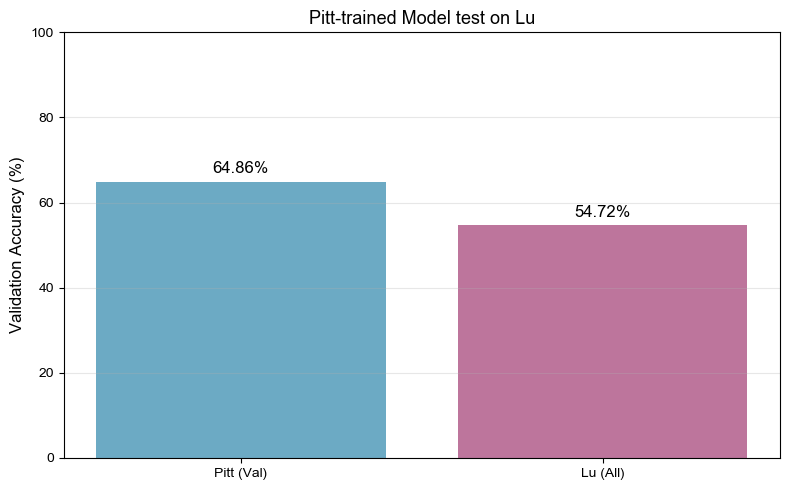


Pitt Validation Accuracy: 64.86%
Lu Accuracy: 54.72%
Performance Drop: 10.14%


In [14]:
# Compare Pitt validation vs Lu test (similar to train_multiple_seeds.ipynb style)
pitt_val_acc = 64.86  # Best model validation accuracy on Pitt
lu_test_acc = accuracy * 100

# Simple comparison plot
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ['Pitt (Val)', 'Lu (All)']
accuracies = [pitt_val_acc, lu_test_acc]

ax.bar(datasets, accuracies, color=['#2E86AB', '#A23B72'], alpha=0.7)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Pitt-trained Model test on Lu', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(accuracies):
    ax.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nPitt Validation Accuracy: {pitt_val_acc:.2f}%")
print(f"Lu Accuracy: {lu_test_acc:.2f}%")
print(f"Performance Drop: {pitt_val_acc - lu_test_acc:.2f}%")
